In [1]:
import pandas as pd

df = pd.read_csv("cleaned_customer_sales.csv")
df.head()

,Customer_ID,Name,Date_of_Birth,Purchase_Date,Purchase_Amount,City,Gender,Customer_Age
0,1654,Customer_1,1979-02-28,2023-01-26,3733.60,Mumbai,Female,47
1,1142,Customer_2,2007-03-15,2023-04-15,3415.83,Bangalore,Male,19
2,1604,Customer_3,1993-02-02,2023-02-02,246.01,Mumbai,Female,33
3,1517,Customer_4,2001-03-03,2023-01-28,2850.10,Pune,Female,25
4,1225,Customer_5,1994-04-25,2024-08-26,1463.13,Kolkata,Male,32


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_ID      1000 non-null   int64  
 1   Name             1000 non-null   object 
 2   Date_of_Birth    1000 non-null   object 
 3   Purchase_Date    1000 non-null   object 
 4   Purchase_Amount  1000 non-null   float64
 5   City             1000 non-null   object 
 6   Gender           1000 non-null   object 
 7   Customer_Age     1000 non-null   int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 62.6+ KB


In [3]:
df.describe()

,Customer_ID,Purchase_Amount,Customer_Age
count,1000.000000,1000.000000,1000.000000
mean,1501.220000,2537.173488,34.090000
std,288.937672,1383.269230,10.582622
min,1001.000000,110.770000,17.000000
25%,1260.500000,1394.777500,25.000000
50%,1494.500000,2537.173488,34.000000
75%,1750.000000,3699.517500,44.000000
max,2000.000000,4996.930000,52.000000


In [4]:
df["City"].value_counts()

City
Kolkata      150
Chennai      149
Bangalore    148
Pune         146
Delhi        138
Mumbai       130
Hyderabad    128
Unknown       11
Name: count, dtype: int64

In [5]:
df["Gender"].value_counts()

Gender
Female    528
Male      472
Name: count, dtype: int64

<Axes: >

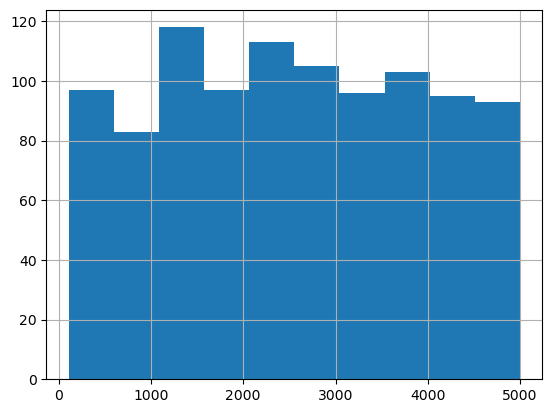

In [6]:
df["Purchase_Amount"].hist()

<Axes: xlabel='City'>

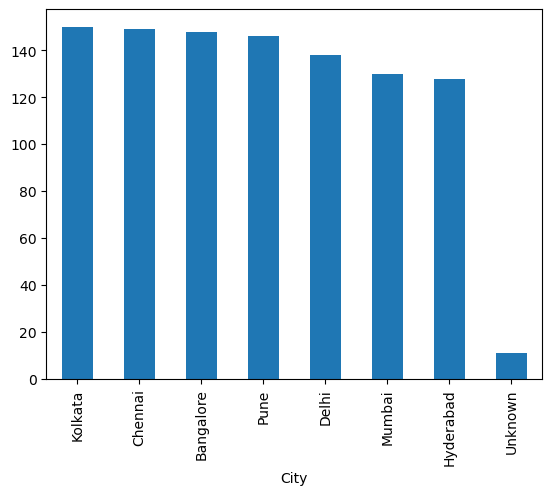

In [7]:
df["City"].value_counts().plot(kind="bar")

In [8]:
import sqlite3


In [9]:
conn = sqlite3.connect("sales.db")

df.to_sql("sales", conn, if_exists="replace", index=False)

1000

In [10]:
pd.read_sql("""
SELECT City, SUM(Purchase_Amount) AS revenue
FROM sales
GROUP BY City
ORDER BY revenue DESC
LIMIT 5
""", conn)

,City,revenue
0,Kolkata,388597.840000
1,Pune,365820.086977
2,Bangalore,364742.480465
3,Chennai,359091.123488
4,Hyderabad,350989.653488


In [11]:
pd.read_sql("""
SELECT Gender, AVG(Purchase_Amount) AS avg_purchase
FROM sales
GROUP BY Gender
""", conn)

,Gender,avg_purchase
0,Female,2558.086453
1,Male,2513.779324


In [12]:
pd.read_sql("""
SELECT strftime('%Y-%m', Purchase_Date) AS month,
SUM(Purchase_Amount) AS total_revenue
FROM sales
GROUP BY month
ORDER BY month
""", conn)

,month,total_revenue
0,2023-01,97738.210000
1,2023-02,106027.053488
2,2023-03,109614.523488
3,2023-04,100660.200000
4,2023-05,116577.303488
5,2023-06,81440.380000
6,2023-07,84162.610000
7,2023-08,103752.830000
8,2023-09,104483.930000
9,2023-10,123570.040000


In [13]:
pd.read_sql("""
SELECT City, COUNT(Customer_ID) AS customers
FROM sales
GROUP BY City
ORDER BY customers DESC
""", conn)

,City,customers
0,Kolkata,150
1,Chennai,149
2,Bangalore,148
3,Pune,146
4,Delhi,138
5,Mumbai,130
6,Hyderabad,128
7,Unknown,11


In [14]:
pd.read_sql("""
SELECT Customer_Age, SUM(Purchase_Amount) AS spending
FROM sales
GROUP BY Customer_Age
ORDER BY spending DESC
LIMIT 10
""", conn)

,Customer_Age,spending
0,22,112251.620000
1,19,108833.740000
2,28,100757.533488
3,49,100581.933488
4,42,89824.360000
5,38,84809.416977
6,18,83835.670000
7,23,83827.326977
8,34,83709.740000
9,32,81030.000000


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

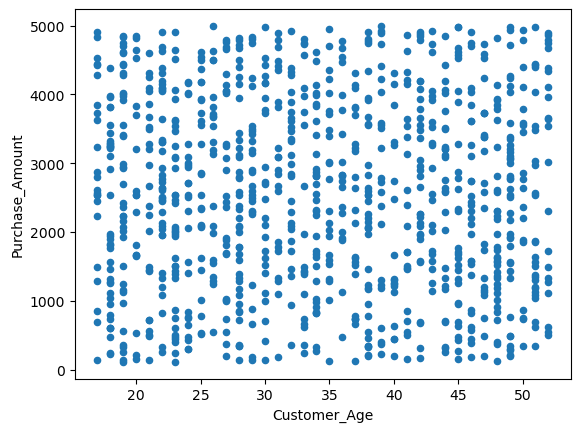

In [16]:
df.plot.scatter(x="Customer_Age", y="Purchase_Amount")
plt.show()

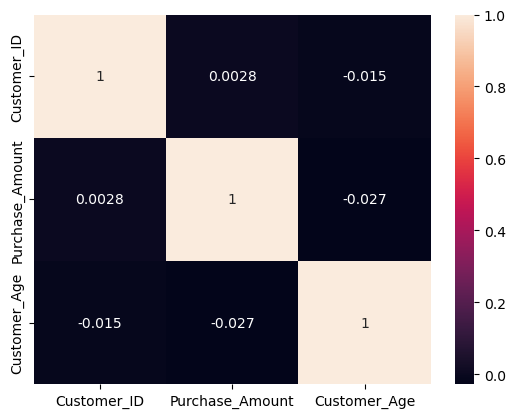

In [17]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

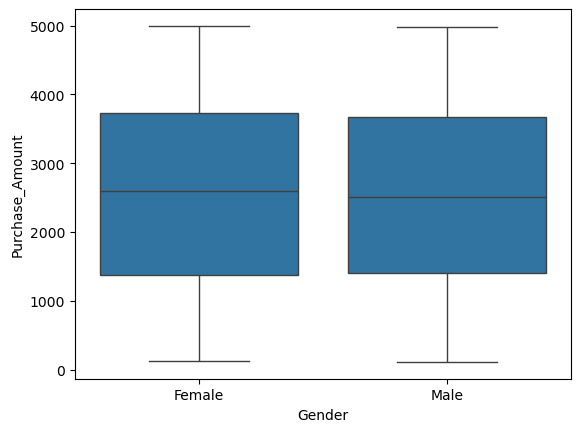

In [18]:
sns.boxplot(x="Gender", y="Purchase_Amount", data=df)
plt.show()